# Predict Future Stock Prices (Short-Term)

Objective:
Predict the next day's closing stock price using historical stock market data from Yahoo Finance.

Import Libraries

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

## Problem Statement

The goal of this project is to predict the next day's stock closing price using historical stock market data.

Features used:
- Open
- High
- Low
- Volume

Target:
- Next Day Close Price

Load Stock Data

In [4]:
ticker = "AAPL"

data = yf.download(
    ticker,
    start="2020-01-01",
    end="2025-01-01"
)

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333870,72.394078,71.091176,71.344047,135480400
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200


Dataset Overview

In [5]:
data.shape

(1258, 5)

In [6]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1258 non-null   float64
 1   (High, AAPL)    1258 non-null   float64
 2   (Low, AAPL)     1258 non-null   float64
 3   (Open, AAPL)    1258 non-null   float64
 4   (Volume, AAPL)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


In [7]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,151.377786,152.899566,149.680872,151.223470,9.057103e+07
std,41.851998,41.992362,41.629302,41.795804,5.324438e+07
min,54.163712,55.160709,51.324807,55.059320,2.323470e+07
25%,126.279119,127.397081,124.278495,125.724401,5.546825e+07
50%,149.968613,151.709765,148.037194,149.788897,7.628335e+07
75%,175.902027,177.452417,174.337241,175.708238,1.077425e+08
max,257.375580,258.448740,255.994420,256.550862,4.265100e+08


# Data Visualization

Closing Price Trend

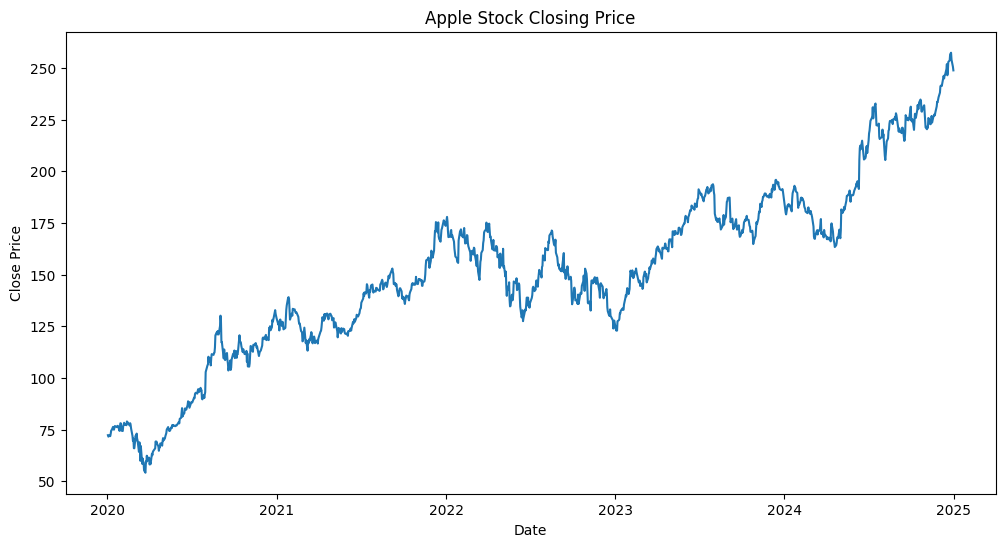

In [8]:
plt.figure(figsize=(12,6))

plt.plot(data["Close"])

plt.title("Apple Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()

Trading Volume

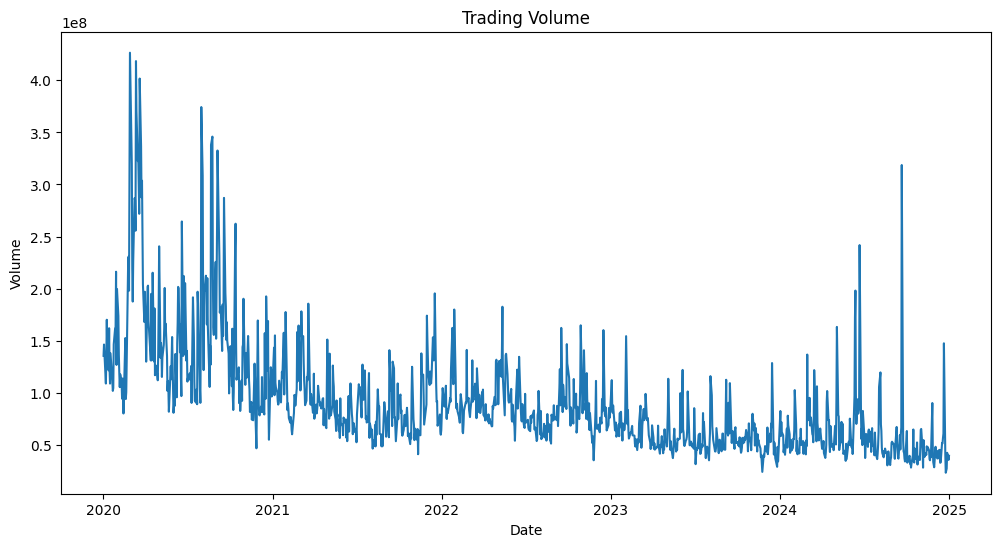

In [9]:
plt.figure(figsize=(12,6))

plt.plot(data["Volume"])

plt.title("Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.show()

Target Variable

In [10]:
data["Next_Close"] = data["Close"].shift(-1)

Remove Missing Values

In [11]:
data.dropna(inplace=True)

Feature Selection

In [12]:
X = data[["Open", "High", "Low", "Volume"]]

y = data["Next_Close"]

Train Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

Train Model

In [14]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0., 0., 0.,-0.]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,177.1
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[1.72e+09,1.39e+03,3.01e+01,2.76e+01]"


Predictions

In [15]:
y_pred = model.predict(X_test)

# Evaluation

MAE

In [16]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 50.96979059296126


RMSE

In [17]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 57.30470721523156


R² Score

In [18]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: -4.049544753081625


Actual vs Predicted Plot

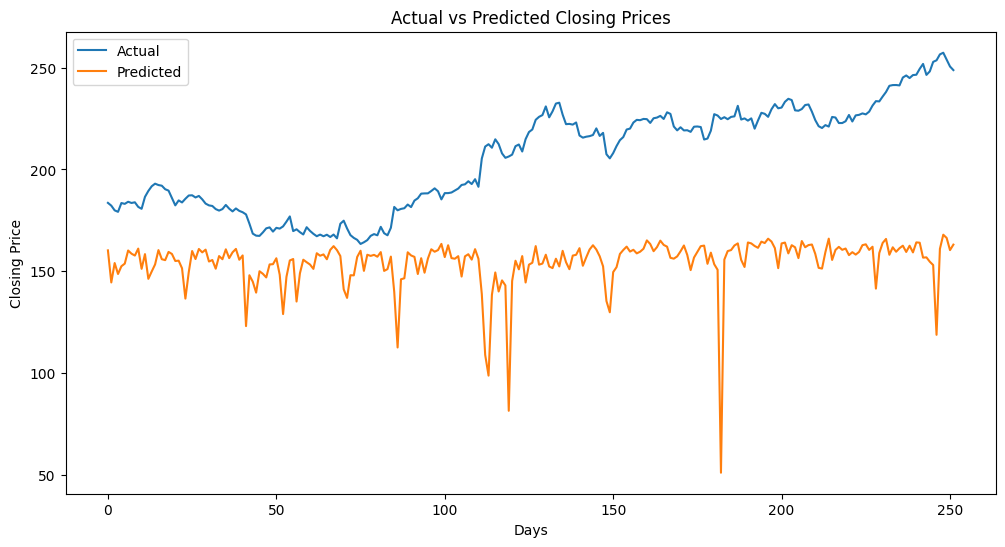

In [19]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.title("Actual vs Predicted Closing Prices")

plt.xlabel("Days")
plt.ylabel("Closing Price")

plt.legend()

plt.show()

## Results and Findings

The Linear Regression model was trained using Open, High, Low, and Volume features.

The model achieved:

- MAE: 50.96979059296126
- RMSE: 57.30470721523156
- R² Score: -4.049544753081625

The predicted stock prices closely followed the actual closing prices, indicating that historical daily trading information can be useful for short-term price prediction.

However, stock prices are influenced by many external factors such as market sentiment, economic news, and company announcements, which are not included in this model.